# Machine Learning Final Proyect - Nopales
### David Villanueva Guzmán - U6110618
### Alvaro Cámara Guerra - U6110583

### Import Required Libraries

In [1]:
import sys
print(sys.executable)
import torch
print(torch.__version__)
print(torch.cuda.is_available())

# import torch.multiprocessing as mp
# mp.set_start_method("spawn", force=True)


c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_venv\Scripts\python.exe
2.2.0+cu118
True


In [2]:
import torch, kornia, platform

print("Torch:", torch.__version__)
print("CUDA version in torch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("Kornia:", kornia.__version__)
print("Python:", platform.python_version())


Torch: 2.2.0+cu118
CUDA version in torch: 11.8
CUDA available: True
Device: NVIDIA GeForce RTX 5060 Laptop GPU
Kornia: 0.8.2
Python: 3.11.9


c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_venv\Lib\site-packages\torch\cuda\__init__.py:218: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [3]:
!nvidia-smi


Sun Dec 14 22:26:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 573.24                 Driver Version: 573.24         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P8              3W /   85W |       0MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# !pip install "numpy<2.0" --force-reinstall
# !pip install kornia
import warnings
warnings.filterwarnings("ignore")

In [5]:
# For data processing
# !pip install pandas
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# Integrate google drive
# from google.colab import drive
# drive.mount('/content/drive')

### Load the Dataset
Milan Dataset --

In [7]:
# Import Multiclass and Binary annotations
file_path_MC = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\annotations_multiclass.csv"
file_path_BIN = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\annotations_binary.csv"
# file_path_MC = "/home/udem09/ifros/machine-learning/annotations_multiclass.csv"
# file_path_BIN = "/home/udem09/ifros/machine-learning/annotations_binary.csv"

# Get dataframes of annotations
df_MC = pd.read_csv(file_path_MC)
df_MC.drop(columns=["Unnamed: 2", "Unnamed: 3"], inplace=True)

print(df_MC.head(10))

  file_prefix printError_physicalDefect
0  001_516_01                       0_0
1  001_516_02                       0_1
2  001_516_03                       0_0
3  001_516_04                       0_0
4  001_516_05                       0_0
5  001_516_06                       0_0
6  001_516_07                       0_0
7  001_516_08                       0_0
8  001_516_09                       0_0
9  001_516_10                       1_0


#### Data Preprocessing

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


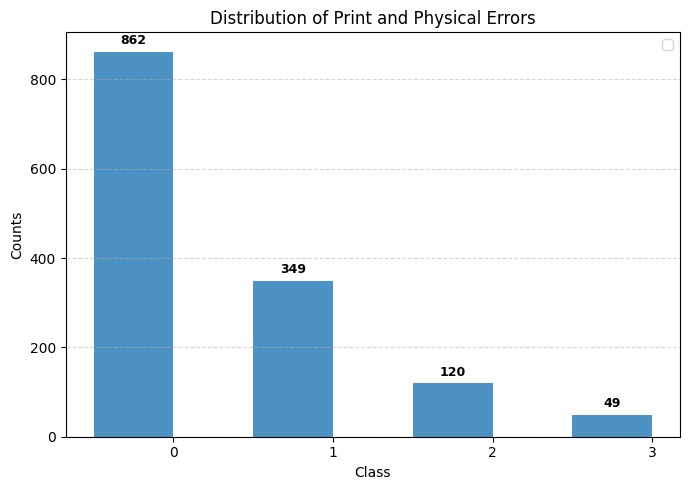

     file_prefix printError_physicalDefect  printError_physicalDefect_int
0     001_516_01                       0_0                              0
1     001_516_02                       0_1                              1
2     001_516_03                       0_0                              0
3     001_516_04                       0_0                              0
4     001_516_05                       0_0                              0
...          ...                       ...                            ...
1375  002_100_11                       0_1                              1
1376  002_100_12                       0_0                              0
1377  002_100_13                       0_0                              0
1378  002_100_14                       0_0                              0
1379  002_100_15                       1_0                              2

[1380 rows x 3 columns]


In [8]:
mapping = {
    "0_0": 0,
    "0_1": 1,
    "1_0": 2,
    "1_1": 3
}

df_MC["printError_physicalDefect_int"] = df_MC["printError_physicalDefect"].map(mapping)

# Count occurrences of each class
print_counts = df_MC["printError_physicalDefect_int"].value_counts().sort_index()

# Create the figure
fig, ax = plt.subplots(figsize=(7, 5))

# Define x positions for side-by-side bars
x = range(len(print_counts))  # same class positions (e.g. 0 and 1)
width = 0.5  # bar width

# Plot bars
bars1 = ax.bar([i - width/2 for i in x], print_counts, width, color='#1f77b4', alpha=0.8)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize axes
ax.set_xlabel("Class")
ax.set_ylabel("Counts")
ax.set_title("Distribution of Print and Physical Errors")
ax.set_xticks(x)
ax.set_xticklabels(print_counts.index)  # e.g. 0 and 1 only
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(df_MC)

### Binary annotations

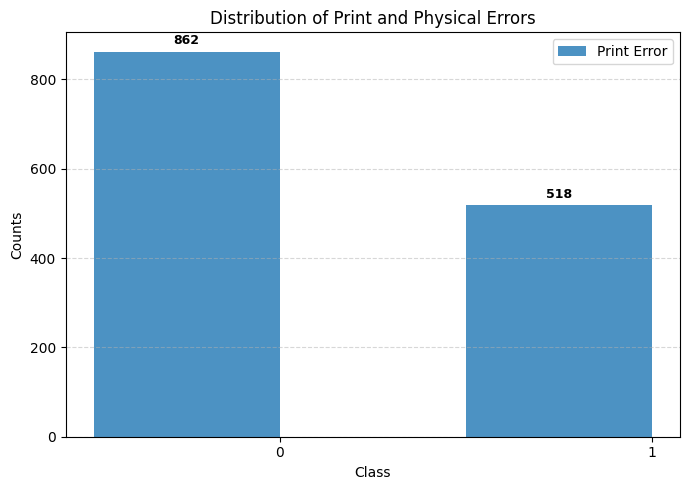

In [9]:
# Lista de strings a buscar en el nombre de la imagen

# Filtrar solo filas donde la segunda columna sea exactamente '0_0'
df_MC["binary"] = (df_MC["printError_physicalDefect_int"] != 0).astype(int)

# Count occurrences of each class
print_counts = df_MC["binary"].value_counts().sort_index()

# Create the figure
fig, ax = plt.subplots(figsize=(7, 5))

# Define x positions for side-by-side bars
x = range(len(print_counts))  # same class positions (e.g. 0 and 1)
width = 0.5  # bar width

# Plot bars
bars1 = ax.bar([i - width/2 for i in x], print_counts, width, label='Print Error', color='#1f77b4', alpha=0.8)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize axes
ax.set_xlabel("Class")
ax.set_ylabel("Counts")
ax.set_title("Distribution of Print and Physical Errors")
ax.set_xticks(x)
ax.set_xticklabels(print_counts.index)  # e.g. 0 and 1 only
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Data reduction

#### Unzip images inside google drive

In [10]:
# extract_path = "/home/udem09/ifros/machine-learning/arrays"
# extract_path = '/content/drive/MyDrive/IFRoS/ML Labs/MILAN-dataset/arrays'
extract_path = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\drive-download-20251113T114126Z-1-001\arrays"

#### Define NPYImageDataset class to load the images

In [11]:
import os
import torch
from torch.utils.data import Dataset
import numpy as np

class NPYImageDataset(Dataset):
    def __init__(self, root_dir, names, labels, transform=None):
        """
        root_dir : Folder with .npy files
        names    : List like ['003_045_012', '002_047_12', ...]
        labels   : Array-like with class labels aligned with 'names'
        transform: torchvision transform
        """
        self.root_dir = root_dir
        self.names = names
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        filename = f"{name}.npy"
        path = os.path.join(self.root_dir, filename)

        # Debugging: Print the path and check if it exists and is a file
        # print(f"Attempting to load: {path}")
        # if not os.path.exists(path):
        #     raise FileNotFoundError(f"File not found: {path}")
        # if not os.path.isfile(path):
        #     raise IOError(f"Path is not a file: {path}")
        ###

        if not os.path.exists(path):
            raise FileNotFoundError(f"File not found: {path}")

        img = np.load(path)                          # (H, W, C)
        img = torch.from_numpy(img).permute(2, 0, 1).float()  # (C, H, W)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx]).long()

        return img, label


In [12]:
all_names = df_MC["file_prefix"].values      # list of .npy filenames
all_labels = df_MC["binary"].values       # 0 / 1 labels

In [13]:
from sklearn.model_selection import train_test_split

# All indices as ints
indices = np.arange(len(all_names))

# Train set
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=all_labels,
    random_state=42
)

# Validation and test set
temp_labels = all_labels[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.10,
    stratify=temp_labels,
    random_state=42
)

In [14]:
# Apply split to names and labels
train_names = all_names[train_idx]
val_names   = all_names[val_idx]
test_names  = all_names[test_idx]

train_labels = all_labels[train_idx]
val_labels   = all_labels[val_idx]
test_labels  = all_labels[test_idx]

#### Data transforming

In [15]:
# For Data Transformation
import torchvision.transforms.v2 as transforms

transform = transforms.Compose([
    # To tensor
    transforms.ToImage(),

    # Scale the images
    transforms.Lambda(lambda x: x / 255.0),  # manually scale to [0,1]
    transforms.ToDtype(torch.float32),        # ensure float32 type

    # Normalize each channel
    transforms.Normalize(mean=[0.5]*6, std=[0.5]*6)
 ])

In [16]:
import torchvision.transforms.v2 as transforms
import torch
import kornia.augmentation as K
import kornia

def scale_image(x):
    return x / 255.0

train_transform = transforms.Compose([
    # Input comes as (C,H,W) torch tensor from NPY
    # Scale to [0,1]
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    # Normalize all 6 channels
    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])

val_transform = transforms.Compose([
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])

test_transform = transforms.Compose([
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])


kornia_augment = torch.nn.Sequential(
    # --- Moderate geometric jitter ---
    K.RandomHorizontalFlip(p=0.4),
    K.RandomRotation(degrees=3.0, p=0.3),
    K.RandomAffine(
        degrees=0,
        translate=(0.04, 0.04),
        scale=(0.96, 1.04),
        p=0.35
    ),

    # --- Stronger photometric jitter ---
    K.RandomBrightness(brightness=(0.90, 1.10), p=0.4),
    K.RandomContrast(contrast=(0.85, 1.15), p=0.4),
    # K.RandomGamma(gamma=(0.8, 1.3), p=0.3),

    # --- Light noise and blur ---
    K.RandomGaussianNoise(mean=0, std=0.01, p=0.3),
    K.RandomGaussianBlur(kernel_size=(3,3), sigma=(0.05, 0.25), p=0.2),

    # --- KEY regularizer: Random erasing ---
    # K.RandomErasing(scale=(0.005, 0.05), ratio=(0.3, 3.3), p=0.35),
)


In [17]:
train_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=train_names,
    labels=train_labels,
    transform=train_transform
)

val_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=val_names,
    labels=val_labels,
    transform=val_transform
)

test_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=test_names,
    labels=test_labels,
    transform=val_transform
)

In [18]:
batch_size = 8

In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0, # Changed from 4 to 0 for debugging
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, # Changed from 4 to 0 for debugging
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, # Changed from commented out to 0 for debugging
    pin_memory=True
)

#### Visuazlie a sample

label =  tensor(1)
Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 6, 310, 310])
Label: tensor(1)


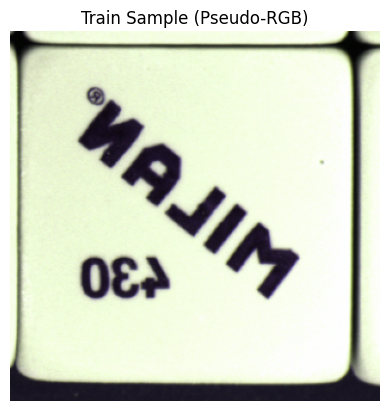

In [20]:
# Visualize ONE sample directly from the DATASET (no batching issues)

import matplotlib.pyplot as plt

# Get one raw sample from the dataset
img, label = train_dataset[0]
print("label = ",label)
img = kornia_augment(img)

print("Type:", type(img))
print("Shape:", img.shape)      # Expected: (1, 6, H, W)
print("Label:", label)

# Undo normalization for visualization
# Since you used: Normalize(mean=[0.5]*6, std=[0.5]*6)
img_vis = img[0, :3] * 0.5 + 0.5   # Take first 3 channels from the first image in batch as pseudo-RGB
img_vis = img_vis.clamp(0, 1)  # Safety clamp

# Show image
plt.imshow(img_vis.permute(1, 2, 0))
plt.title("Train Sample (Pseudo-RGB)")
plt.axis("off")
plt.show()

### Setting the Device

### Define structure

In [21]:
# Import pretrained model ResNet50
import torchvision.models as models
import numpy as np
import torch.nn as nn

# Hyperparameters
dropout_rate = 0.3
num_classes = 2

# Imported model
imported_model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1, progress = True)

# Freeze layers
# frozen_layers = ("conv1", "layer1", "layer2")
frozen_layers = ("layer1")
for name, param in imported_model.named_parameters():
    if name.startswith(frozen_layers):
        param.requires_grad = False
    else:
        param.requires_grad = True

old_weight = imported_model.conv1.weight  # [64, 3, 7, 7]
old_conv = imported_model.conv1
new_conv = nn.Conv2d(
    in_channels=6,             # change from 3 to 6
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=old_conv.bias
  )
with torch.no_grad():
    new_conv.weight[:, :3].copy_(old_weight)
    new_conv.weight[:, 3:].copy_(old_weight.clone())
imported_model.conv1 = new_conv

imported_model.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(dropout_rate),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(dropout_rate-0.1),

    nn.Linear(128, 2) 
)
# For resrnet34
layer_groups = {
    "conv1": ["conv1", "bn1"],
    "layer1": ["layer1"],
    "layer2": ["layer2"],
    "layer3": ["layer3"],
    "layer4": ["layer4"],
    "head":   ["fc"],   # classifier
}



### Train the model

### Train and Validation Fucntions

In [22]:
import torch, kornia, platform
# Define device foor runtime
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Torch:", torch.__version__)
print("CUDA version in torch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("Kornia:", kornia.__version__)
print("Python:", platform.python_version())
print(device)


Torch: 2.2.0+cu118
CUDA version in torch: 11.8
CUDA available: True
Device: NVIDIA GeForce RTX 5060 Laptop GPU
Kornia: 0.8.2
Python: 3.11.9
cuda


In [23]:
#train function
from sklearn.metrics import average_precision_score, f1_score
import torch.nn.functional as F
import numpy as np

def Train(model, train_loader, optimizer):
    model.train()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    for i, (images, labels) in enumerate(train_loader):


        # Move augmented batch to GPU for training
        images = images.to(device)
        labels = labels.to(device)

        # Data augmentation with kornia in the GPU 
        images = kornia_augment(images)

        # Initialize backpropagation and optimization
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Backpropagation
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Convert logits → probability of positive class
        probs = F.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    # Compute AUC-PR for the full epoch
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # AUC-PR
    if len(np.unique(all_labels)) > 1:
        auc_pr = average_precision_score(all_labels, all_probs)
    else:
        auc_pr = 0.0

    # Average loss
    avg_loss = running_loss / len(train_loader)

    # Binary predictions for F1
    preds = (all_probs >= 0.5).astype(int)

    # F1-score
    f1 = f1_score(all_labels, preds)

    return avg_loss, auc_pr, f1

#validation function
def Validate(model, val_loader):
    model.eval()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            # Convert logits → probability of positive class
            probs = F.softmax(outputs, dim=1)[:, 1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    auc_pr = average_precision_score(all_labels, all_probs)
    avg_loss = running_loss / len(val_loader)

    # # Binary predictions for F1
    # preds = (all_probs >= 0.5).astype(int)

    # # F1-score
    # f1 = f1_score(all_labels, preds)

    # ----- FIND BEST THRESHOLD FOR F1 -----
    thresholds = np.linspace(0.0, 1.0, 200)
    f1_scores = [
        f1_score(all_labels, (all_probs >= t).astype(int)) 
        for t in thresholds
    ]
    best_idx = int(np.argmax(f1_scores))
    best_threshold = float(thresholds[best_idx])
    best_f1 = float(f1_scores[best_idx])

    return avg_loss, auc_pr, best_f1, best_threshold

In [24]:
import os
import numpy as np

bad_files = []
good = 0

for f in os.listdir(extract_path):
    if not f.lower().endswith(".npy"):
        continue

    full = os.path.join(extract_path, f)

    try:
        arr = np.load(full)
        _ = arr.shape  # force read
        good += 1
    except Exception as e:
        print("❌ Bad file:", full)
        print("   Error:", repr(e))
        bad_files.append(full)

print("\n✅ Good files:", good)
print("❌ Bad files:", len(bad_files))



✅ Good files: 1380
❌ Bad files: 0


In [25]:
# ============================================
# FOCAL LOSS - Para datasets desbalanceados
# ============================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Focal Loss para clasificación binaria/multiclase con desbalance.

    Parámetros:
    -----------
    alpha : tensor o None
        Peso para cada clase. Ej: [0.3, 0.7] da más peso a clase 1
    gamma : float
        Factor de enfoque. Típicamente 2.0
        - gamma=0 equivale a CrossEntropyLoss
        - gamma>0 reduce la pérdida para ejemplos bien clasificados
    label_smoothing : float
        Suavizado de etiquetas (0.0 a 0.2 típicamente)
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # será un tensor en GPU
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        inputs: logits del modelo, shape (N, C) donde C=num_classes
        targets: etiquetas, shape (N,) con valores 0 o 1
        """
        # Calcular log-softmax para estabilidad numérica
        log_probs = F.log_softmax(inputs, dim=1)

        # Obtener log_prob de la clase correcta para cada muestra
        # targets.unsqueeze(1) -> (N, 1)
        # gather selecciona el log_prob correspondiente a la clase correcta
        ce_loss = F.nll_loss(log_probs, targets, reduction='none')

        # Probabilidad de la clase correcta
        probs = torch.exp(log_probs)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Focal weight: (1 - pt)^gamma
        focal_weight = (1 - pt) ** self.gamma

        # Aplicar focal weight
        focal_loss = focal_weight * ce_loss

        # Aplicar alpha (peso por clase) si está definido
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            focal_loss = alpha_t * focal_loss

        # Reducción
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [26]:
# Optimizer and Criterion
def compute_class_stats_from_loader(loader):
    total_per_class = torch.zeros(2)

    for _, labels in loader:
        for c in [0, 1]:
            total_per_class[c] += (labels == c).sum()

    N0 = int(total_per_class[0].item())  # non-defective
    N1 = int(total_per_class[1].item())  # defective

    return N0, N1


# Class distribution
N0, N1 = compute_class_stats_from_loader(train_loader)
print("Non-defective:", N0)
print("Defective:", N1)

# Calculate the weights
beta = 0.999
w0 = (1 - beta) / (1 - beta**N0)
w1 = (1 - beta) / (1 - beta**N1)

weights = torch.tensor([w0, w1]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.035)

alpha = torch.tensor([0.35, 0.65]).to(device)  # suma = 1.0

# gamma controla cuánto enfocarse en ejemplos difíciles
# gamma=2.0 es el valor típico del paper original
# criterion = FocalLoss(
#     alpha=alpha,
#     gamma=2.0,
#     label_smoothing=0.05  
# )

# Define optimizer
optimizer = torch.optim.AdamW(imported_model.parameters(), lr=1e-4, weight_decay=5e-5)

# Parse model to the GPU
imported_model = imported_model.to(device)

Non-defective: 603
Defective: 363


In [27]:
print(device)

cuda


In [28]:
num_epochs = 200
patience = 15
min_delta = 1e-3

best_val_aucpr = 0.0
epochs_no_improve = 0
best_model_state = None

In [29]:
print(imported_model)

ResNet(
  (conv1): Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
def apply_freezing(model, layer_groups: list[str], layers_to_modify: list[str], freeze_flag: bool):
    """
    freeze_flag: True → freeze layers, False → unfreeze layers
    layers_to_modify: list of keys from layer_groups,
    """

    target_substrings = []
    for key in layers_to_modify:
        target_substrings += layer_groups[key]

    for name, module in model.named_modules():
        if any(substr in name for substr in target_substrings):
            for param in module.parameters():
                param.requires_grad = (not freeze_flag)  # True→freeze means requires_grad=False

def build_optimizer(model, lr: float, wd: float):
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    return torch.optim.AdamW(
        trainable_params,
        lr=lr,
        weight_decay=wd
    )

# optimizer = torch.optim.AdamW(imported_model.parameters(), lr=learning_rate, weight_decay=5e-5)


In [31]:
# Hyperparameters
learning_rate = 1e-4
weight_decay = 1e-4

# Train schedulers for alternate freezing layers
freeze_schedule = [
    # Phase 1: freeze layer 1
    (5, True,  ["layer1"], 5e-5),
    # (10,  False, [], 1e-4),

    # Phase 2: freeze layer 2
    (5, True,  ["layer2"], 5e-5),

    # Phase 3: unfreeze layer 1
    (5, False,  ["layer1"], 5e-5),

    # Phase 4: unfreeze layer 2
    (200, False, ["layer2"], 1e-5)
]

# Tracking lists
train_losses = []
val_losses = []
train_aucprs = []
val_aucprs = []
train_f1s = []
val_f1s = []

# Early stopping parameters
best_val_aucpr = 0.0
best_epoch = 0
epochs_no_improve = 0
current_epoch = 0

for block_epochs, freeze_flag, layers_to_modify, lr in freeze_schedule:

    print(f"\n=== New Training Block: {block_epochs} epochs | freeze={freeze_flag} | layers={layers_to_modify} ===")

    # Freeze/unfreeze layers
    apply_freezing(imported_model, layer_groups, layers_to_modify, freeze_flag)

    # Rebuild optimizer to include only unfrozen parameters
    optimizer = build_optimizer(imported_model, lr, weight_decay)

    # Rebuild scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # Train inside this block
    for _ in range(block_epochs):

        # Safety break if total num_epochs is reached
        if current_epoch >= num_epochs: break

        # ---- Training ----
        train_loss, train_aucpr, train_f1 = Train(imported_model, train_loader, optimizer)
        val_loss, val_aucpr, val_f1, val_best_th = Validate(imported_model, val_loader)

        # Log metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_aucprs.append(train_aucpr)
        val_aucprs.append(val_aucpr)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        print(
            f"Epoch [{current_epoch+1}/{num_epochs}] "
            f"| Freeze={freeze_flag} | Layers={layers_to_modify} "
            f"| Train Loss={train_loss:.4f} Train AUC={train_aucpr:.4f} "
            f"| Val Loss={val_loss:.4f} Val AUC={val_aucpr:.4f}"
        )

        # ---- EARLY STOPPING ----
        if val_aucpr > best_val_aucpr + min_delta:
            best_val_aucpr = val_aucpr
            best_epoch = current_epoch + 1
            epochs_no_improve = 0
            best_model_state = imported_model.state_dict()
            best_threshold = val_best_th
        else:
            epochs_no_improve += 1
            print(f"  EarlyStopping counter: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print("\nEarly stopping triggered!\n")
            break

        # Step scheduler
        scheduler.step()
        current_epoch += 1

    if epochs_no_improve >= patience:
        break

# Restore best weights
imported_model.load_state_dict(best_model_state)
print(f"\nBest model restored (Epoch {best_epoch} | AUC-PR={best_val_aucpr:.4f})")



=== New Training Block: 5 epochs | freeze=True | layers=['layer1'] ===
Epoch [1/200] | Freeze=True | Layers=['layer1'] | Train Loss=0.7286 Train AUC=0.4259 | Val Loss=0.6493 Val AUC=0.5658
Epoch [2/200] | Freeze=True | Layers=['layer1'] | Train Loss=0.7065 Train AUC=0.4449 | Val Loss=0.6752 Val AUC=0.5601
  EarlyStopping counter: 1/15
Epoch [3/200] | Freeze=True | Layers=['layer1'] | Train Loss=0.7039 Train AUC=0.4392 | Val Loss=0.6776 Val AUC=0.5285
  EarlyStopping counter: 2/15
Epoch [4/200] | Freeze=True | Layers=['layer1'] | Train Loss=0.6839 Train AUC=0.5047 | Val Loss=0.6515 Val AUC=0.5994
Epoch [5/200] | Freeze=True | Layers=['layer1'] | Train Loss=0.6642 Train AUC=0.5665 | Val Loss=0.6105 Val AUC=0.7258

=== New Training Block: 5 epochs | freeze=True | layers=['layer2'] ===
Epoch [6/200] | Freeze=True | Layers=['layer2'] | Train Loss=0.6502 Train AUC=0.5862 | Val Loss=0.5886 Val AUC=0.7007
  EarlyStopping counter: 1/15
Epoch [7/200] | Freeze=True | Layers=['layer2'] | Train Lo

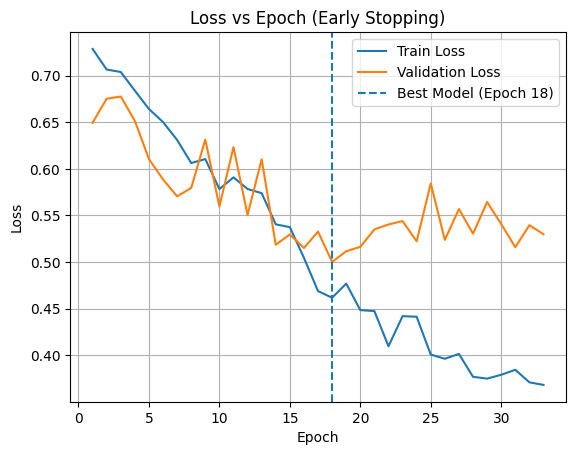

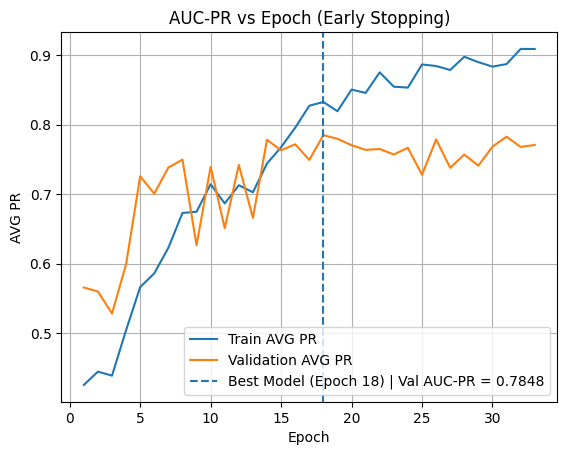

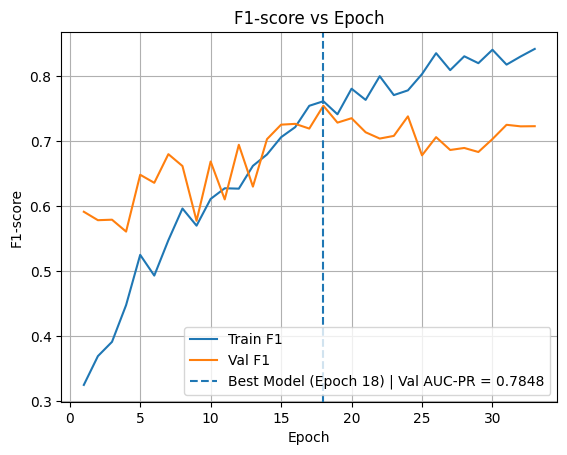

In [32]:
epochs = list(range(1, len(train_losses) + 1))

# -------- LOSS PLOT --------
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch})'
)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch (Early Stopping)')
plt.legend()
plt.grid(True)
plt.show()

# -------- AUC-PR PLOT --------
plt.figure()
plt.plot(epochs, train_aucprs, label='Train AVG PR')
plt.plot(epochs, val_aucprs, label='Validation AVG PR')
plt.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch}) | Val AUC-PR = {best_val_aucpr:.4f}'
)
plt.xlabel('Epoch')
plt.ylabel('AVG PR')
plt.title('AUC-PR vs Epoch (Early Stopping)')
plt.legend()
plt.grid(True)
plt.show()

# -------- F1 SCORE PLOT --------
plt.figure()
plt.plot(epochs, train_f1s, label="Train F1")
plt.plot(epochs, val_f1s, label="Val F1")
plt.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch}) | Val AUC-PR = {best_val_aucpr:.4f}'
)
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("F1-score vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [33]:
# ============================================
# GUARDAR MODELO (ejecutar justo después del training loop)
# ============================================
import torch

# Guardar el mejor modelo
torch.save(best_model_state, "best_model.pt")
print("✅ Modelo guardado: best_model.pt")

✅ Modelo guardado: best_model.pt


In [34]:
# ============================================
# INSTALAR PYTORCH 2.2 Y NUMPY COMPATIBLE
# (Ejecutar solo si tienes PyTorch 2.9)
# ============================================
import torch
print(f"PyTorch actual: {torch.__version__}")

# Si es 2.9.x, ejecutar esto:
# !pip install torch==2.2.0 torchvision==0.17.0 --index-url https://download.pytorch.org/whl/cu118
# !pip install "numpy<2"
# Luego: Runtime → Restart session

PyTorch actual: 2.2.0+cu118


AUC-PR: 0.7598


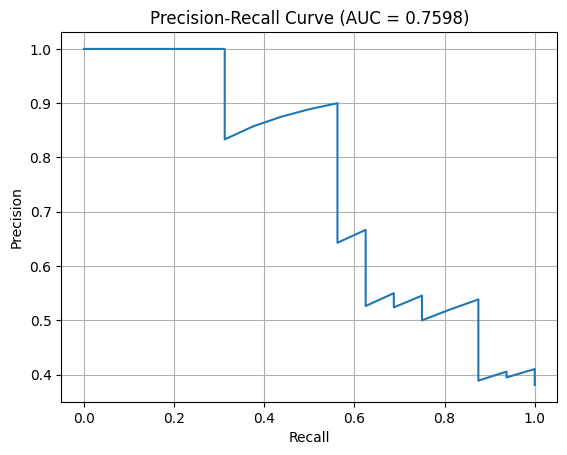

Labels distribution: [26 16]


In [35]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import torch.nn.functional as F

imported_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = imported_model(images)

        # Probabilidad de clase positiva (defecto = clase 1)
        probs = F.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

auc_pr = average_precision_score(all_labels, all_probs)
print(f"AUC-PR: {auc_pr:.4f}")

# Convert lists to numpy arrays
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

# Compute AUC-PR
auc_pr = average_precision_score(all_labels, all_probs)

# Plot
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {auc_pr:.4f})")
plt.grid(True)
plt.show()

print("Labels distribution:", np.bincount(all_labels.astype(int)))


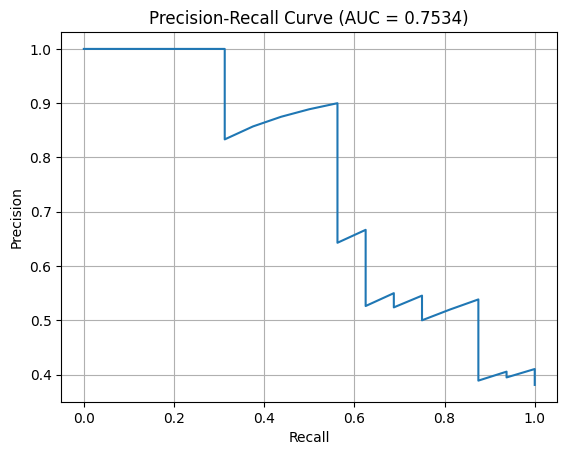

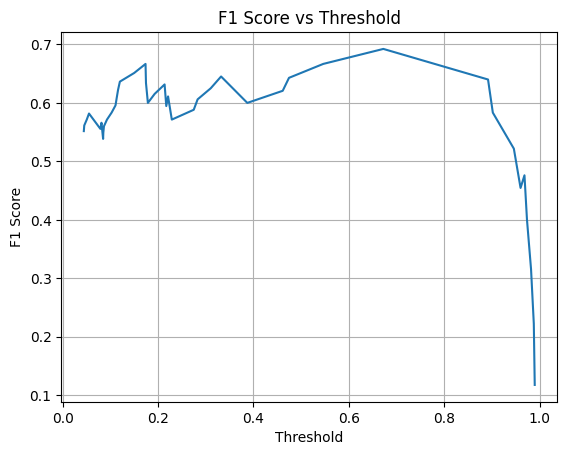

AUC-PR: 0.7534
Best F1: 0.6923
Best Threshold: 0.6724


In [36]:
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

imported_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = imported_model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]

        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

y_scores = torch.cat(all_probs).numpy()
y_true = torch.cat(all_labels).numpy()

# ---- PR Curve ----
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
auc_pr = auc(recall, precision)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {auc_pr:.4f})")
plt.grid(True)
plt.show()

# ---- F1 vs Threshold ----
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_f1 = f1_scores[best_idx]
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

plt.figure()
plt.plot(thresholds, f1_scores[:-1])
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.grid(True)
plt.show()

print(f"AUC-PR: {auc_pr:.4f}")
print(f"Best F1: {best_f1:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")


## Saving the model

In [37]:
# !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cu118
# !pip install onnx onnxruntime onnxscript


In [38]:
# ============================================
# EXPORTAR A ONNX - ARQUITECTURA CORREGIDA
# ============================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Recrear arquitectura CORRECTA
model = models.resnet34(weights=None)
model.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Arquitectura FC correcta (la que usaste al entrenar)
model.fc = nn.Sequential(
    nn.Linear(512, 256),      # fc.0
    nn.BatchNorm1d(256),      # fc.1
    nn.ReLU(),                # fc.2
    nn.Dropout(p=0.25),        # fc.6
    nn.Linear(256, 128),      # fc.3
    nn.BatchNorm1d(128),      # fc.4
    nn.ReLU(),                # fc.5
    nn.Dropout(p=0.2),        # fc.6
    nn.Linear(128, 2)         # fc.7
)

# Cargar pesos
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model = model.to(device)
model.eval()

print("✅ Modelo cargado correctamente")

# Verificar predicción
with torch.no_grad():
    dummy = torch.rand(1, 6, 310, 310).to(device)
    out = model(dummy)
    prob = F.softmax(out, dim=1)[0, 1].item()
print(f"Predicción de prueba: {prob:.4f}")

# Exportar a ONNX
onnx_filename = "model_final.onnx"
torch.onnx.export(
    imported_model, # Original model 
    # model,
    dummy,
    onnx_filename,
    opset_version=14,
    input_names=['input'],
    output_names=['output'],
    do_constant_folding=True
)
print(f"✅ Exportado: {onnx_filename}")

✅ Modelo cargado correctamente
Predicción de prueba: 0.0836
✅ Exportado: model_final.onnx


In [39]:
# ============================================
# VERIFICAR QUE ONNX == PYTORCH
# ============================================
import onnxruntime as ort
import numpy as np
import torch
import torch.nn.functional as F

# Cargar ONNX
ort_session = ort.InferenceSession("model_final.onnx", providers=["CPUExecutionProvider"])

# Comparar predicciones
print("Comparando PyTorch vs ONNX:")
for i in range(5):
    test_input = torch.rand(1, 6, 310, 310)
    
    # PyTorch
    with torch.no_grad():
        pt_prob = F.softmax(model(test_input.to(device)), dim=1)[0, 1].item()
    
    # ONNX
    onnx_out = ort_session.run(None, {"input": test_input.numpy()})[0]
    onnx_prob = (np.exp(onnx_out) / np.exp(onnx_out).sum())[0, 1]
    
    print(f"   Test {i+1}: PyTorch={pt_prob:.4f}, ONNX={onnx_prob:.4f}, Diff={abs(pt_prob-onnx_prob):.6f}")

# Si Diff > 0.01 hay problema

Comparando PyTorch vs ONNX:
   Test 1: PyTorch=0.0899, ONNX=0.0899, Diff=0.000000
   Test 2: PyTorch=0.0782, ONNX=0.0782, Diff=0.000000
   Test 3: PyTorch=0.0861, ONNX=0.0861, Diff=0.000000
   Test 4: PyTorch=0.0846, ONNX=0.0846, Diff=0.000000
   Test 5: PyTorch=0.0861, ONNX=0.0861, Diff=0.000000


In [40]:
# ============================================
# EVALUAR AUC-PR CON ONNX EN TEST SET
# ============================================
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import average_precision_score
import onnxruntime as ort

ort_session = ort.InferenceSession("model_final.onnx", providers=["CPUExecutionProvider"])

pytorch_probs = []
onnx_probs = []
labels_list = []

# model.eval()
imported_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        # PyTorch
        # outputs = model(images.to(device))
        outputs = imported_model(images.to(device))
        probs_pt = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        pytorch_probs.extend(probs_pt)
        labels_list.extend(labels.numpy())
        
        # ONNX
        for i in range(images.shape[0]):
            single = images[i:i+1].numpy()
            out = ort_session.run(None, {"input": single})[0]
            prob = (np.exp(out) / np.exp(out).sum(axis=1, keepdims=True))[0, 1]
            onnx_probs.append(prob)

pytorch_probs = np.array(pytorch_probs)
onnx_probs = np.array(onnx_probs)
labels_arr = np.array(labels_list)

auc_pytorch = average_precision_score(labels_arr, pytorch_probs)
auc_onnx = average_precision_score(labels_arr, onnx_probs)

print(f"PyTorch AUC-PR: {auc_pytorch:.4f} (Min={pytorch_probs.min():.4f}, Max={pytorch_probs.max():.4f})")
print(f"ONNX AUC-PR:    {auc_onnx:.4f} (Min={onnx_probs.min():.4f}, Max={onnx_probs.max():.4f})")

if abs(auc_pytorch - auc_onnx) < 0.01:
    print("\n✅ ONNX funciona correctamente")
else:
    print("\n❌ Hay diferencia - revisar exportación")

PyTorch AUC-PR: 0.7598 (Min=0.0443, Max=0.9899)
ONNX AUC-PR:    0.7598 (Min=0.0443, Max=0.9899)

✅ ONNX funciona correctamente


In [41]:
# ============================================
# CREAR SUBMISSION.PY
# ============================================

submission_code = '''#!/usr/bin/env python3
import os, sys, csv, glob
import numpy as np
import onnxruntime as ort

def parse_args():
    if len(sys.argv) != 4:
        raise SystemExit('Usage: python submission.py <model_path> <images_dir> <output_csv>')
    return sys.argv[1], sys.argv[2], sys.argv[3]

def load_model(model_path):
    return ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])

def preprocess_image(arr):
    arr = arr.astype(np.float32)
    if arr.max() > 1.0:
        arr = arr / 255.0
    if arr.ndim == 3 and arr.shape[-1] == 6:
        arr = np.transpose(arr, (2, 0, 1))
    arr = (arr - 0.5) / 0.5
    return arr[np.newaxis, :, :, :]

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

def preprocess_data(images_dir):
    arrays_dir = os.path.join(images_dir, "arrays")
    if not os.path.isdir(arrays_dir):
        arrays_dir = images_dir
    for path in sorted(glob.glob(os.path.join(arrays_dir, "*.npy"))):
        file_prefix = os.path.basename(path).replace(".npy", "")
        yield file_prefix, preprocess_image(np.load(path))

def run_inference(session, input_array):
    result = session.run(None, {session.get_inputs()[0].name: input_array})[0]
    return float(softmax(result[0])[1])

def write_csv(predictions, output_csv):
    with open(output_csv, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['file_prefix', 'error'])
        for file_prefix, prob in predictions:
            writer.writerow([file_prefix, prob])

def main():
    model_path, images_dir, output_csv = parse_args()
    model = load_model(model_path)
    predictions = [(fp, run_inference(model, tensor)) for fp, tensor in preprocess_data(images_dir)]
    write_csv(predictions, output_csv)

if __name__ == '__main__':
    main()
'''

with open('submission.py', 'w') as f:
    f.write(submission_code)

print("✅ submission.py creado")

✅ submission.py creado


In [42]:
# Expor the test dataset into a new folder for testing
import shutil
import pandas as pd
import stat
import time

EXPORT_DIR = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test"
EXPORT_ARRAYS = os.path.join(EXPORT_DIR, "arrays")

# -------- Remove previous export completely --------
def remove_readonly(func, path, exc):
    os.chmod(path, stat.S_IWRITE)
    func(path)

for _ in range(5):
    try:
        shutil.rmtree(EXPORT_DIR, onerror=remove_readonly)
        break
    except PermissionError:
        print("Directory locked, retrying...")
        time.sleep(0.3)

os.makedirs(EXPORT_ARRAYS, exist_ok=True)

print("\nExporting test dataset to:", EXPORT_ARRAYS)

# Folder containing ALL 1380 original .npy images
# Collect paths and labels for CSV
csv_rows = []
for name, label in zip(test_names, test_labels):
    src = os.path.join(extract_path, f"{name}.npy")
    dst = os.path.join(EXPORT_ARRAYS, f"{name}.npy")

    if not os.path.exists(src):
        raise FileNotFoundError(f"Missing .npy file: {src}")

    shutil.copy(src, dst)
    csv_rows.append([name, int(label)])

print(f"Copied {len(csv_rows)} test images.")

# Save labels CSV
csv_path = os.path.join(EXPORT_DIR, "labels.csv")
df = pd.DataFrame(csv_rows, columns=["file_prefix", "binary"])
df.to_csv(csv_path, index=False)

print(f"Saved labels to: {csv_path}")
print("\nTest dataset export complete.\n")


Exporting test dataset to: C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test\arrays
Copied 42 test images.
Saved labels to: C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test\labels.csv

Test dataset export complete.



In [43]:
# ============================================
# PROBAR SUBMISSION.PY LOCALMENTE
# ============================================

# !python submission.py "model_final.onnx" "/home/udem09/ifros/machine-learning/" "test_predictions.csv"
!python submission.py "model_final.onnx" "C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test" "C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test\labels.csv"

# Verificar resultado
import pandas as pd
from sklearn.metrics import average_precision_score

preds = pd.read_csv(r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test\labels.csv")
merged = preds.merge(df_MC[['file_prefix', 'binary']], on='file_prefix')
auc = average_precision_score(merged['binary'], merged['error'])

print(f"Predicciones: {len(preds)}")
print(f"AUC-PR: {auc:.4f}")
print(f"Rango: {preds['error'].min():.4f} - {preds['error'].max():.4f}")

Predicciones: 42
AUC-PR: 0.7598
Rango: 0.0443 - 0.9899


In [44]:
# ============================================
# EVALUAR SOLO EN TEST SET
# ============================================
import pandas as pd
from sklearn.metrics import average_precision_score

# Cargar predicciones
preds = pd.read_csv(r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test\labels.csv")

# Crear DataFrame con solo los del test set
test_df = pd.DataFrame({
    'file_prefix': test_names,
    'binary': test_labels
})

# Merge solo con test set
merged = preds.merge(test_df, on='file_prefix')

print(f"Total predicciones: {len(preds)}")
print(f"Predicciones en TEST SET: {len(merged)}")

auc = average_precision_score(merged['binary'], merged['error'])

print(f"\n📊 AUC-PR (Test Set): {auc:.4f}")
print(f"Rango: {merged['error'].min():.4f} - {merged['error'].max():.4f}")

Total predicciones: 42
Predicciones en TEST SET: 42

📊 AUC-PR (Test Set): 0.7598
Rango: 0.0443 - 0.9899


## Testing the model